<a href="https://colab.research.google.com/github/parinitha672/QUICK-CART-STOCKOUT/blob/main/QuickCart_Stockout_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
stores = pd.read_csv(
    "/content/dim_stores.csv"
)
skus = pd.read_csv(
    "/content/dim_skus.csv"
)
suppliers = pd.read_csv(
    "/content/dim_suppliers.csv",
    na_values=["N/A", "missing", "--", "NA", "null"]
)
events = pd.read_csv(
    "/content/dim_events.csv",
    parse_dates=["date"]
)
fact = pd.read_csv(
    "/content/fact_inventory_daily.csv",
    parse_dates=["date"],
    na_values=["N/A", "missing", "--", "NA", "null"]
)
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [ ]:
print("DIM_STORES")
print("Rows:", stores.shape[0], " | Columns:", stores.shape[1])
print()
print("DIM_SKUS")
print("Rows:", skus.shape[0], " | Columns:", skus.shape[1])
print()
print("DIM_SUPPLIERS")
print("Rows:", suppliers.shape[0], " | Columns:", suppliers.shape[1])
print()
print("DIM_EVENTS")
print("Rows:", events.shape[0], " | Columns:", events.shape[1])
print()
print("FACT_INVENTORY_DAILY")
print("Rows:", fact.shape[0], " | Columns:", fact.shape[1])

DIM_STORES
Rows: 12  | Columns: 8

DIM_SKUS
Rows: 60  | Columns: 9

DIM_SUPPLIERS
Rows: 15  | Columns: 6

DIM_EVENTS
Rows: 30  | Columns: 5

FACT_INVENTORY_DAILY
Rows: 21600  | Columns: 16


In [ ]:
print("Stores columns:")
print(stores.columns.tolist())
print("\nSKUs columns:")
print(skus.columns.tolist())
print("\nSuppliers columns:")
print(suppliers.columns.tolist())
print("\nEvents columns:")
print(events.columns.tolist())
print("\nFact table columns:")
print(fact.columns.tolist())

Stores columns:
['store_id', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders']

SKUs columns:
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

Suppliers columns:
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']

Events columns:
['date', 'event_name', 'event_type', 'demand_multiplier_festive', 'demand_multiplier_other']

Fact table columns:
['date', 'store_id', 'sku_id', 'supplier_id', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk']


In [ ]:
target_counts = fact["stockout_risk"].value_counts()
target_percent = (
    fact["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})
print(target_summary)

               Count  Percentage
stockout_risk                   
Safe           14131       65.42
At-Risk         5186       24.01
Imminent        2283       10.57


In [ ]:
print("Minimum date:", fact["date"].min())
print("Maximum date:", fact["date"].max())
print("Unique dates:", fact["date"].nunique())

Minimum date: 2026-10-01 00:00:00
Maximum date: 2026-10-30 00:00:00
Unique dates: 30


In [ ]:
print("Missing values in each table:\n")
print("----- STORES -----")
print(stores.isnull().sum())
print("\n----- SKUS -----")
print(skus.isnull().sum())
print("\n----- SUPPLIERS -----")
print(suppliers.isnull().sum())
print("\n----- EVENTS -----")
print(events.isnull().sum())
print("\n----- FACT -----")
print(fact.isnull().sum())

Missing values in each table:

----- STORES -----
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

----- SKUS -----
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

----- SUPPLIERS -----
supplier_id                0
supplier_name              0
categories_supplied        0
reliability_score          3
base_lead_time_days        0
lead_time_variance_days    0
dtype: int64

----- EVENTS -----
date                         0
event_name                   0
event_type                   0
demand_multiplier_festive    0
demand_multiplier_other      0
dtype: int64

----- FACT -----
date                           0
store_id                       0
sku_id    

In [ ]:
missing_actual_lead = fact["lead_time_days_actual"].isna().sum()
available_actual_lead = fact["lead_time_days_actual"].notna().sum()
print("Missing actual lead time:", missing_actual_lead)
print("Available actual lead time:", available_actual_lead)
print("Total rows:", len(fact))

Missing actual lead time: 19899
Available actual lead time: 1701
Total rows: 21600


In [ ]:
duplicate_count = fact.duplicated(
    subset=["date", "store_id", "sku_id"]
).sum()
print("Duplicate store-SKU-date rows:", duplicate_count)

Duplicate store-SKU-date rows: 0


In [ ]:
print("Duplicate store IDs:",
      stores["store_id"].duplicated().sum())
print("Duplicate SKU IDs:",
      skus["sku_id"].duplicated().sum())
print("Duplicate supplier IDs:",
      suppliers["supplier_id"].duplicated().sum())

Duplicate store IDs: 0
Duplicate SKU IDs: 0
Duplicate supplier IDs: 0


In [ ]:
print("City values:")
print(stores[["store_id", "city", "city_display"]].to_string(index=False))

City values:
store_id      city city_display
    ST01    Mumbai       Mumbai
    ST02    Mumbai       Mumbai
    ST03 Bengaluru    BENGALURU
    ST04 Bengaluru    Bengaluru
    ST05     Delhi        Delhi
    ST06     Delhi        Delhi
    ST07      Pune         Pune
    ST08      Pune         Pune
    ST09 Hyderabad    hyderabad
    ST10 Hyderabad    Hyderabad
    ST11   Chennai      Chennai
    ST12   Chennai      Chennai


In [ ]:
print("Supplier reliability values:")
print(
    suppliers[
        ["supplier_id", "supplier_name", "reliability_score"]
    ].to_string(index=False)
)

Supplier reliability values:
supplier_id             supplier_name  reliability_score
      SUP01            Fresh Farms Co               0.92
      SUP02 Green Valley Distributors               0.93
      SUP03      Metro Dairy Supplies               0.90
      SUP04      Sunrise Agro Traders               0.70
      SUP05       National Snacks Ltd               0.66
      SUP06     QuickBev Distributors                NaN
      SUP07        CarePlus Wholesale               0.67
      SUP08        HomeShine Supplies               0.73
      SUP09      Golden Grain Traders               0.72
      SUP10        Daily Bakes Supply               0.66
      SUP11     Coastal Foods Pvt Ltd               0.83
      SUP12         Bharat Staples Co               0.63
      SUP13   Urban FMCG Distributors               0.91
      SUP14       Prime Personal Care                NaN
      SUP15      Regional Produce Hub                NaN


In [ ]:
stores["city_display"] = stores["city_display"].str.title()
print(stores[["store_id", "city", "city_display"]])

   store_id       city city_display
0      ST01     Mumbai       Mumbai
1      ST02     Mumbai       Mumbai
2      ST03  Bengaluru    Bengaluru
3      ST04  Bengaluru    Bengaluru
4      ST05      Delhi        Delhi
5      ST06      Delhi        Delhi
6      ST07       Pune         Pune
7      ST08       Pune         Pune
8      ST09  Hyderabad    Hyderabad
9      ST10  Hyderabad    Hyderabad
10     ST11    Chennai      Chennai
11     ST12    Chennai      Chennai


In [ ]:
reliability_median = suppliers["reliability_score"].median()
print("Median reliability:", reliability_median)
suppliers["reliability_score_clean"] = (
    suppliers["reliability_score"]
    .fillna(reliability_median)
)
print("\nCleaned supplier reliability:")
print(
    suppliers[
        ["supplier_id", "reliability_score", "reliability_score_clean"]
    ]
)

Median reliability: 0.725

Cleaned supplier reliability:
   supplier_id  reliability_score  reliability_score_clean
0        SUP01               0.92                    0.920
1        SUP02               0.93                    0.930
2        SUP03               0.90                    0.900
3        SUP04               0.70                    0.700
4        SUP05               0.66                    0.660
5        SUP06                NaN                    0.725
6        SUP07               0.67                    0.670
7        SUP08               0.73                    0.730
8        SUP09               0.72                    0.720
9        SUP10               0.66                    0.660
10       SUP11               0.83                    0.830
11       SUP12               0.63                    0.630
12       SUP13               0.91                    0.910
13       SUP14                NaN                    0.725
14       SUP15                NaN                    0.725

In [ ]:
print("Missing reliability before cleaning:",
      suppliers["reliability_score"].isna().sum())
print("Missing reliability after cleaning:",
      suppliers["reliability_score_clean"].isna().sum())

Missing reliability before cleaning: 3
Missing reliability after cleaning: 0


In [ ]:
suppliers_model = suppliers[
    [
        "supplier_id",
        "supplier_name",
        "categories_supplied",
        "reliability_score_clean",
        "base_lead_time_days",
        "lead_time_variance_days"
    ]
].copy()
print("Supplier model table:", suppliers_model.shape)

Supplier model table: (15, 6)


In [ ]:
skus_model = skus.copy()
print("SKU model table:", skus_model.shape)

SKU model table: (60, 9)


In [ ]:
stores_model = stores.copy()
print("Store model table:", stores_model.shape)

Store model table: (12, 8)


In [ ]:
events_model = events.copy()
print("Events model table:", events_model.shape)

Events model table: (30, 5)


In [ ]:
model_df = fact.copy()
print("Starting fact table shape:", model_df.shape)

Starting fact table shape: (21600, 16)


In [ ]:
model_df = model_df.merge(
    skus_model,
    on="sku_id",
    how="left",
    validate="many_to_one"
)
print("After SKU join:", model_df.shape)

After SKU join: (21600, 24)


In [ ]:
import pandas as pd
import numpy as np
stores = pd.read_csv("/content/dim_stores.csv")
skus = pd.read_csv("/content/dim_skus.csv")
suppliers = pd.read_csv(
    "/content/dim_suppliers.csv",
    na_values=["N/A", "missing", "--", "NA", "null"]
)
events = pd.read_csv(
    "/content/dim_events.csv",
    parse_dates=["date"]
)
fact = pd.read_csv(
    "/content/fact_inventory_daily.csv",
    parse_dates=["date"],
    na_values=["N/A", "missing", "--", "NA", "null"]
)
print("All five datasets loaded successfully.")
print("Fact table:", fact.shape)

All five datasets loaded successfully.
Fact table: (21600, 16)


In [ ]:
stores["city_display"] = stores["city_display"].str.title()
reliability_median = suppliers["reliability_score"].median()
suppliers["reliability_score_clean"] = (
    suppliers["reliability_score"]
    .fillna(reliability_median)
)
print("City and supplier data cleaned.")
print("Reliability median:", reliability_median)
print(
    "Remaining missing reliability:",
    suppliers["reliability_score_clean"].isna().sum()
)

City and supplier data cleaned.
Reliability median: 0.725
Remaining missing reliability: 0


In [ ]:
model_df = fact.copy()
print("Starting fact table shape:", model_df.shape)

Starting fact table shape: (21600, 16)


In [ ]:
model_df = model_df.merge(
    skus,
    on="sku_id",
    how="left",
    validate="many_to_one"
)
print("After SKU join:", model_df.shape)

After SKU join: (21600, 24)


In [ ]:
print(model_df.columns.tolist())

['date', 'store_id', 'sku_id', 'supplier_id_x', 'opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'reorder_placed', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'is_festival_week', 'stockout_risk', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id_y']


In [ ]:
model_df["supplier_id"] = model_df["supplier_id_x"]
model_df = model_df.drop(
    columns=["supplier_id_x", "supplier_id_y"]
)
print("supplier_id fixed successfully.")
print("Current shape:", model_df.shape)
print("supplier_id exists:", "supplier_id" in model_df.columns)

supplier_id fixed successfully.
Current shape: (21600, 23)
supplier_id exists: True


In [ ]:
suppliers_model = suppliers[
    [
        "supplier_id",
        "supplier_name",
        "categories_supplied",
        "reliability_score_clean",
        "base_lead_time_days",
        "lead_time_variance_days"
    ]
].copy()
model_df = model_df.merge(
    suppliers_model,
    on="supplier_id",
    how="left",
    validate="many_to_one"
)
print("After supplier join:", model_df.shape)

After supplier join: (21600, 28)


In [ ]:
stores_model = stores[
    [
        "store_id",
        "city",
        "city_display",
        "city_tier",
        "store_size",
        "sqft",
        "opened_year",
        "baseline_daily_orders"
    ]
].copy()
model_df = model_df.merge(
    stores_model,
    on="store_id",
    how="left",
    validate="many_to_one"
)
print("After store join:", model_df.shape)

After store join: (21600, 35)


In [ ]:
events_model = events[
    [
        "date",
        "event_name",
        "event_type",
        "demand_multiplier_festive",
        "demand_multiplier_other"
    ]
].copy()
model_df = model_df.merge(
    events_model,
    on="date",
    how="left",
    validate="many_to_one"
)
print("After events join:", model_df.shape)

After events join: (21600, 39)


In [ ]:
print("Final modeling dataset shape:", model_df.shape)
assert len(model_df) == 21600, (
    f"Expected 21600 rows, but got {len(model_df)}"
)
print("✅ Final row-count validation passed!")

Final modeling dataset shape: (21600, 39)
✅ Final row-count validation passed!


In [ ]:
print("Final dataset shape:", model_df.shape)
print("\nFirst 5 rows:")
display(model_df.head())

Final dataset shape: (21600, 39)

First 5 rows:


,date,store_id,sku_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,...,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,159.9,15,15.0,144.9,36.4,N,1,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,144.9,10,10.0,134.9,36.4,N,1,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,134.9,15,15.0,119.9,36.4,N,1,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,119.9,10,10.0,109.9,36.4,N,1,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,109.9,9,9.0,100.9,36.4,N,1,...,Mumbai,Tier1,Large,2946,2023,580,Regular Day,none,1.0,1.0


In [ ]:
print("Final dataset information:")
model_df.info()

Final dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       21600 non-null  datetime64[ns]
 1   store_id                   21600 non-null  object        
 2   sku_id                     21600 non-null  object        
 3   opening_stock              21600 non-null  float64       
 4   units_demanded             21600 non-null  int64         
 5   units_sold                 21600 non-null  float64       
 6   closing_stock              21600 non-null  float64       
 7   reorder_point              21600 non-null  float64       
 8   reorder_placed             21600 non-null  object        
 9   lead_time_days_expected    21600 non-null  int64         
 10  lead_time_days_actual      1701 non-null   float64       
 11  sales_velocity_7d          21600 non-nul

In [ ]:
print("Missing values in final dataset:")
missing_final = model_df.isna().sum()
print(
    missing_final[missing_final > 0]
    .sort_values(ascending=False)
)

Missing values in final dataset:
lead_time_days_actual    19899
dtype: int64


In [ ]:
print("Rows with missing SKU name:",
      model_df["sku_name"].isna().sum())
print("Rows with missing supplier name:",
      model_df["supplier_name"].isna().sum())
print("Rows with missing city:",
      model_df["city"].isna().sum())
print("Rows with missing event name:",
      model_df["event_name"].isna().sum())

Rows with missing SKU name: 0
Rows with missing supplier name: 0
Rows with missing city: 0
Rows with missing event name: 0


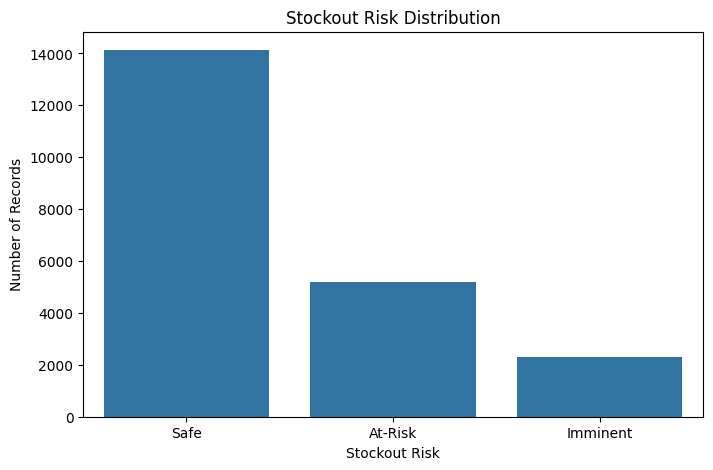

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.countplot(
    data=model_df,
    x="stockout_risk",
    order=["Safe", "At-Risk", "Imminent"]
)
plt.title("Stockout Risk Distribution")
plt.xlabel("Stockout Risk")
plt.ylabel("Number of Records")
plt.show()

In [ ]:
risk_percentage = (
    model_df["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print("Stockout Risk Percentage:")
print(risk_percentage)

Stockout Risk Percentage:
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


In [ ]:
category_risk = pd.crosstab(
    model_df["category"],
    model_df["stockout_risk"],
    normalize="index"
).mul(100).round(2)
print(category_risk)

stockout_risk        At-Risk  Imminent   Safe
category                                     
Bakery                 26.34     26.11  47.55
Beverages              22.08     14.55  63.37
Dairy                  14.48      7.54  77.98
Fruits & Vegetables    27.19      7.93  64.88
Home Care              20.60      8.52  70.88
Personal Care          19.17      6.79  74.05
Snacks                 28.98     10.19  60.83
Staples                30.14      5.83  64.03


In [ ]:
festival_risk = (
    model_df
    .groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .round(2)
)
print("Imminent rate by festival status:")
print(festival_risk)

Imminent rate by festival status:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64


In [ ]:
def reliability_band(x):
    if x < 0.75:
        return "Low"
    elif x < 0.85:
        return "Medium"
    else:
        return "High"
model_df["reliability_band"] = (
    model_df["reliability_score_clean"]
    .apply(reliability_band)
)
reliability_risk = (
    model_df
    .groupby("reliability_band")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .reindex(["Low", "Medium", "High"])
    .round(2)
)
print("Imminent rate by supplier reliability:")
print(reliability_risk)

Imminent rate by supplier reliability:
reliability_band
Low       13.07
Medium     3.26
High       3.82
Name: stockout_risk, dtype: float64


In [ ]:
perishable_risk = (
    model_df
    .groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .round(2)
)
print("Imminent rate by perishability:")
print(perishable_risk)

Imminent rate by perishability:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


In [ ]:
cover_summary = (
    model_df
    .groupby("stockout_risk")["days_of_cover"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)
print(cover_summary)

                mean  median  min     max
stockout_risk                            
At-Risk         4.05    3.82  1.0    8.80
Imminent        1.95    1.72  0.0    7.88
Safe           10.64   10.05  4.0  134.85


In [ ]:
model_df["reorder_gap"] = (
    model_df["reorder_point"] -
    model_df["closing_stock"]
)
print(model_df["reorder_gap"].describe().round(2))

count    21600.00
mean       -53.54
std        104.71
min       -810.00
25%        -78.50
50%        -26.30
75%          0.00
max        393.50
Name: reorder_gap, dtype: float64


In [ ]:
model_df["days_of_cover_ratio"] = (
    model_df["days_of_cover"] /
    model_df["lead_time_days_expected"]
)
print(model_df["days_of_cover_ratio"].describe().round(2))

count    21600.00
mean         4.70
std          4.49
min          0.00
25%          1.63
50%          3.14
75%          6.48
max        134.85
Name: days_of_cover_ratio, dtype: float64


In [ ]:
model_df["day_of_month"] = (
    model_df["date"].dt.day
)
print(
    model_df["day_of_month"]
    .value_counts()
    .sort_index()
)

day_of_month
1     720
2     720
3     720
4     720
5     720
6     720
7     720
8     720
9     720
10    720
11    720
12    720
13    720
14    720
15    720
16    720
17    720
18    720
19    720
20    720
21    720
22    720
23    720
24    720
25    720
26    720
27    720
28    720
29    720
30    720
Name: count, dtype: int64


In [ ]:
festival_start = pd.Timestamp("2026-10-22")
model_df["days_since_festival_start"] = (
    model_df["date"] - festival_start
).dt.days
print(
    model_df[
        ["date", "days_since_festival_start"]
    ].drop_duplicates().head(25)
)

         date  days_since_festival_start
0  2026-10-01                        -21
1  2026-10-02                        -20
2  2026-10-03                        -19
3  2026-10-04                        -18
4  2026-10-05                        -17
5  2026-10-06                        -16
6  2026-10-07                        -15
7  2026-10-08                        -14
8  2026-10-09                        -13
9  2026-10-10                        -12
10 2026-10-11                        -11
11 2026-10-12                        -10
12 2026-10-13                         -9
13 2026-10-14                         -8
14 2026-10-15                         -7
15 2026-10-16                         -6
16 2026-10-17                         -5
17 2026-10-18                         -4
18 2026-10-19                         -3
19 2026-10-20                         -2
20 2026-10-21                         -1
21 2026-10-22                          0
22 2026-10-23                          1
23 2026-10-24   

In [ ]:
model_df = model_df.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)

In [ ]:
model_df["reorder_last_day"] = (
    model_df
    .groupby(["store_id", "sku_id"])["reorder_placed"]
    .shift(1)
)
model_df["is_recent_reorder"] = (
    model_df["reorder_last_day"]
    .eq("Y")
    .astype(int)
)
model_df = model_df.drop(
    columns=["reorder_last_day"]
)
print(
    model_df["is_recent_reorder"]
    .value_counts()
)

is_recent_reorder
0    19960
1     1640
Name: count, dtype: int64


In [ ]:
new_features = [
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "is_recent_reorder"
]
print(
    model_df[new_features]
    .describe()
    .round(2)
)

       reorder_gap  days_of_cover_ratio  day_of_month  \
count     21600.00             21600.00      21600.00   
mean        -53.54                 4.70         15.50   
std         104.71                 4.49          8.66   
min        -810.00                 0.00          1.00   
25%         -78.50                 1.63          8.00   
50%         -26.30                 3.14         15.50   
75%           0.00                 6.48         23.00   
max         393.50               134.85         30.00   

       days_since_festival_start  is_recent_reorder  
count                   21600.00           21600.00  
mean                       -6.50               0.08  
std                         8.66               0.26  
min                       -21.00               0.00  
25%                       -14.00               0.00  
50%                        -6.50               0.00  
75%                         1.00               0.00  
max                         8.00               1.00  


In [ ]:
print("Current columns:")
for i, col in enumerate(model_df.columns, start=1):
    print(i, "→", col)

Current columns:
1 → date
2 → store_id
3 → sku_id
4 → opening_stock
5 → units_demanded
6 → units_sold
7 → closing_stock
8 → reorder_point
9 → reorder_placed
10 → lead_time_days_expected
11 → lead_time_days_actual
12 → sales_velocity_7d
13 → days_of_cover
14 → is_festival_week
15 → stockout_risk
16 → sku_name
17 → category
18 → unit_price_inr
19 → shelf_life_days
20 → is_perishable
21 → festive_relevant
22 → popularity_tier
23 → supplier_id
24 → supplier_name
25 → categories_supplied
26 → reliability_score_clean
27 → base_lead_time_days
28 → lead_time_variance_days
29 → city
30 → city_display
31 → city_tier
32 → store_size
33 → sqft
34 → opened_year
35 → baseline_daily_orders
36 → event_name
37 → event_type
38 → demand_multiplier_festive
39 → demand_multiplier_other
40 → reliability_band
41 → reorder_gap
42 → days_of_cover_ratio
43 → day_of_month
44 → days_since_festival_start
45 → is_recent_reorder


In [ ]:
y = model_df["stockout_risk"].copy()
feature_columns = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "reorder_placed",
    "lead_time_days_expected",
    "lead_time_days_actual",
    "sales_velocity_7d",
    "days_of_cover",
    "is_festival_week",
    "category",
    "unit_price_inr",
    "shelf_life_days",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "reliability_score_clean",
    "base_lead_time_days",
    "lead_time_variance_days",
    "city",
    "city_tier",
    "store_size",
    "sqft",
    "baseline_daily_orders",
    "event_type",
    "demand_multiplier_festive",
    "demand_multiplier_other",
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "is_recent_reorder"
]
X = model_df[feature_columns].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (21600, 33)
y shape: (21600,)

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [ ]:
print("Target column:", y.name)
print("Number of features:", X.shape[1])
print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())
print("\nNumeric features:")
print(X.select_dtypes(exclude=["object"]).columns.tolist())

Target column: stockout_risk
Number of features: 33

Categorical features:
['reorder_placed', 'is_festival_week', 'category', 'is_perishable', 'festive_relevant', 'popularity_tier', 'city', 'city_tier', 'store_size', 'event_type']

Numeric features:
['opening_stock', 'units_demanded', 'units_sold', 'closing_stock', 'reorder_point', 'lead_time_days_expected', 'lead_time_days_actual', 'sales_velocity_7d', 'days_of_cover', 'unit_price_inr', 'shelf_life_days', 'reliability_score_clean', 'base_lead_time_days', 'lead_time_variance_days', 'sqft', 'baseline_daily_orders', 'demand_multiplier_festive', 'demand_multiplier_other', 'reorder_gap', 'days_of_cover_ratio', 'day_of_month', 'days_since_festival_start', 'is_recent_reorder']


In [ ]:
train_mask = model_df["date"] <= pd.Timestamp("2026-10-23")
test_mask = model_df["date"] >= pd.Timestamp("2026-10-24")
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining dates:")
print(model_df.loc[train_mask, "date"].min())
print(model_df.loc[train_mask, "date"].max())
print("\nTesting dates:")
print(model_df.loc[test_mask, "date"].min())
print(model_df.loc[test_mask, "date"].max())

Training rows: 16560
Testing rows: 5040

Training dates:
2026-10-01 00:00:00
2026-10-23 00:00:00

Testing dates:
2026-10-24 00:00:00
2026-10-30 00:00:00


In [ ]:
print("TRAINING TARGET DISTRIBUTION")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print("\nTESTING TARGET DISTRIBUTION")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

TRAINING TARGET DISTRIBUTION
stockout_risk
Safe        66.38
At-Risk     24.52
Imminent     9.11
Name: proportion, dtype: float64

TESTING TARGET DISTRIBUTION
stockout_risk
Safe        62.28
At-Risk     22.34
Imminent    15.38
Name: proportion, dtype: float64


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessor created successfully.")

Numeric features: 23
Categorical features: 10
Preprocessor created successfully.


In [ ]:
from sklearn.dummy import DummyClassifier
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])
dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)
print("Dummy baseline trained successfully.")

Dummy baseline trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
dummy_accuracy = accuracy_score(
    y_test,
    dummy_predictions
)
dummy_macro_f1 = f1_score(
    y_test,
    dummy_predictions,
    average="macro"
)
print("Dummy Baseline")
print("----------------")
print("Accuracy :", round(dummy_accuracy, 4))
print("Macro-F1 :", round(dummy_macro_f1, 4))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dummy_predictions,
        zero_division=0
    )
)

Dummy Baseline
----------------
Accuracy : 0.6228
Macro-F1 : 0.2559

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [ ]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)
logistic_macro_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="macro"
)
print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Macro-F1 :", round(logistic_macro_f1, 4))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression
-------------------
Accuracy : 0.9431
Macro-F1 : 0.9058

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.93      0.81      0.86      1126
    Imminent       0.80      0.94      0.86       775
        Safe       0.99      0.99      0.99      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.91      0.91      5040
weighted avg       0.95      0.94      0.94      5040



In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)
rf_macro_f1 = f1_score(
    y_test,
    rf_predictions,
    average="macro"
)
print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Macro-F1 :", round(rf_macro_f1, 4))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest
-------------
Accuracy : 0.9514
Macro-F1 : 0.9106

Classification Report:
              precision    recall  f1-score   support

     At-Risk       0.86      0.93      0.90      1126
    Imminent       0.89      0.79      0.84       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.95      5040
   macro avg       0.92      0.91      0.91      5040
weighted avg       0.95      0.95      0.95      5040



In [3]:
import pandas as pd
import numpy as np
stores = pd.read_csv("/content/dim_stores.csv")
skus = pd.read_csv("/content/dim_skus.csv")
suppliers = pd.read_csv(
    "/content/dim_suppliers.csv",
    na_values=["N/A", "missing", "--", "NA", "null"]
)
events = pd.read_csv(
    "/content/dim_events.csv",
    parse_dates=["date"]
)
fact = pd.read_csv(
    "/content/fact_inventory_daily.csv",
    parse_dates=["date"],
    na_values=["N/A", "missing", "--", "NA", "null"]
)
stores["city_display"] = stores["city_display"].str.title()
reliability_median = suppliers["reliability_score"].median()
suppliers["reliability_score_clean"] = (
    suppliers["reliability_score"]
    .fillna(reliability_median)
)
model_df = fact.copy()
model_df = model_df.merge(
    skus,
    on="sku_id",
    how="left",
    validate="many_to_one"
)
model_df["supplier_id"] = model_df["supplier_id_x"]
model_df = model_df.drop(
    columns=["supplier_id_x", "supplier_id_y"]
)
suppliers_model = suppliers[
    [
        "supplier_id",
        "supplier_name",
        "categories_supplied",
        "reliability_score_clean",
        "base_lead_time_days",
        "lead_time_variance_days"
    ]
].copy()
model_df = model_df.merge(
    suppliers_model,
    on="supplier_id",
    how="left",
    validate="many_to_one"
)
stores_model = stores[
    [
        "store_id",
        "city",
        "city_display",
        "city_tier",
        "store_size",
        "sqft",
        "opened_year",
        "baseline_daily_orders"
    ]
].copy()
model_df = model_df.merge(
    stores_model,
    on="store_id",
    how="left",
    validate="many_to_one"
)
events_model = events[
    [
        "date",
        "event_name",
        "event_type",
        "demand_multiplier_festive",
        "demand_multiplier_other"
    ]
].copy()
model_df = model_df.merge(
    events_model,
    on="date",
    how="left",
    validate="many_to_one"
)
model_df["reliability_band"] = (
    model_df["reliability_score_clean"]
    .apply(
        lambda x:
        "Low" if x < 0.75
        else "Medium" if x < 0.85
        else "High"
    )
)
model_df["reorder_gap"] = (
    model_df["reorder_point"] -
    model_df["closing_stock"]
)
model_df["days_of_cover_ratio"] = (
    model_df["days_of_cover"] /
    model_df["lead_time_days_expected"]
)
model_df["day_of_month"] = (
    model_df["date"].dt.day
)
festival_start = pd.Timestamp("2026-10-22")
model_df["days_since_festival_start"] = (
    model_df["date"] -
    festival_start
).dt.days
model_df = model_df.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)
model_df["reorder_last_day"] = (
    model_df
    .groupby(["store_id", "sku_id"])["reorder_placed"]
    .shift(1)
)
model_df["is_recent_reorder"] = (
    model_df["reorder_last_day"]
    .eq("Y")
    .astype(int)
)
model_df = model_df.drop(
    columns=["reorder_last_day"]
)
print("================================")
print("PROJECT STATE RESTORED")
print("================================")
print("model_df shape:", model_df.shape)
print("Target distribution:")
print(model_df["stockout_risk"].value_counts())

PROJECT STATE RESTORED
model_df shape: (21600, 45)
Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64


In [5]:
feature_columns = [
    "opening_stock",
    "units_demanded",
    "units_sold",
    "closing_stock",
    "reorder_point",
    "reorder_placed",
    "lead_time_days_expected",
    "lead_time_days_actual",
    "sales_velocity_7d",
    "days_of_cover",
    "is_festival_week",
    "category",
    "unit_price_inr",
    "shelf_life_days",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "reliability_score_clean",
    "base_lead_time_days",
    "lead_time_variance_days",
    "city",
    "city_tier",
    "store_size",
    "sqft",
    "baseline_daily_orders",
    "event_type",
    "demand_multiplier_festive",
    "demand_multiplier_other",
    "reorder_gap",
    "days_of_cover_ratio",
    "day_of_month",
    "days_since_festival_start",
    "is_recent_reorder"
]
X = model_df[feature_columns].copy()
y = model_df["stockout_risk"].copy()
test_mask = model_df["date"] >= pd.Timestamp("2026-10-24")
X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nTest target distribution:")
print(y_test.value_counts())

X shape: (21600, 33)
y shape: (21600,)
X_test shape: (5040, 33)
y_test shape: (5040,)

Test target distribution:
stockout_risk
Safe        3139
At-Risk     1126
Imminent     775
Name: count, dtype: int64


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)
X = model_df[feature_columns].copy()
y = model_df["stockout_risk"].copy()
train_mask = model_df["date"] <= pd.Timestamp("2026-10-23")
test_mask = model_df["date"] >= pd.Timestamp("2026-10-24")
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()
print("Training:", X_train.shape)
print("Testing :", X_test.shape)
numeric_features = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])

dummy_model.fit(X_train, y_train)
dummy_predictions = dummy_model.predict(X_test)
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
random_forest_model.fit(X_train, y_train)
rf_predictions = random_forest_model.predict(X_test)
results = []
models_and_predictions = [
    ("Dummy Baseline", dummy_predictions),
    ("Logistic Regression", logistic_predictions),
    ("Random Forest", rf_predictions)
]
for model_name, predictions in models_and_predictions:
    accuracy = accuracy_score(
        y_test,
        predictions
    )
    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Macro-F1": round(macro_f1, 4)
    })
model_comparison = pd.DataFrame(results)
print("\n================================")
print("FINAL MODEL COMPARISON")
print("================================")
print(
    model_comparison.to_string(index=False)
)
print("\n\nDUMMY BASELINE")
print("----------------")
print(
    classification_report(
        y_test,
        dummy_predictions,
        zero_division=0
    )
)
print("\nLOGISTIC REGRESSION")
print("-------------------")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)
print("\nRANDOM FOREST")
print("-------------")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Training: (16560, 33)
Testing : (5040, 33)

FINAL MODEL COMPARISON
              Model  Accuracy  Macro-F1
     Dummy Baseline    0.6228    0.2559
Logistic Regression    0.9431    0.9058
      Random Forest    0.9514    0.9106


DUMMY BASELINE
----------------
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040


LOGISTIC REGRESSION
-------------------
              precision    recall  f1-score   support

     At-Risk       0.93      0.81      0.86      1126
    Imminent       0.80      0.94      0.86       775
        Safe       0.99      0.99      0.99      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.91      0.91  

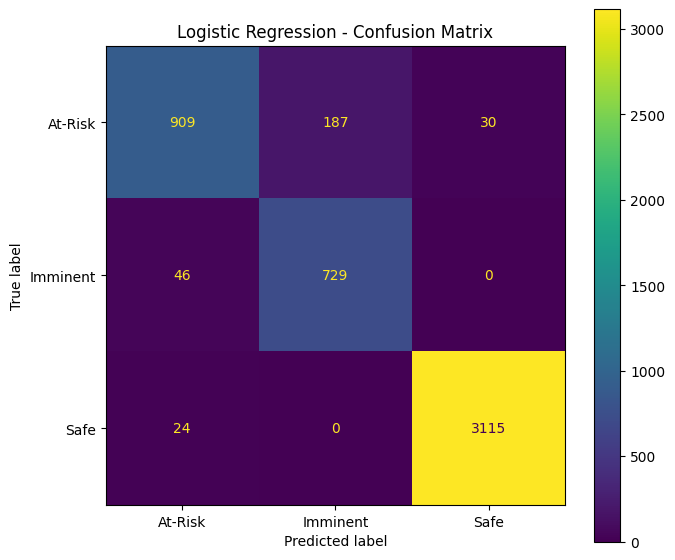

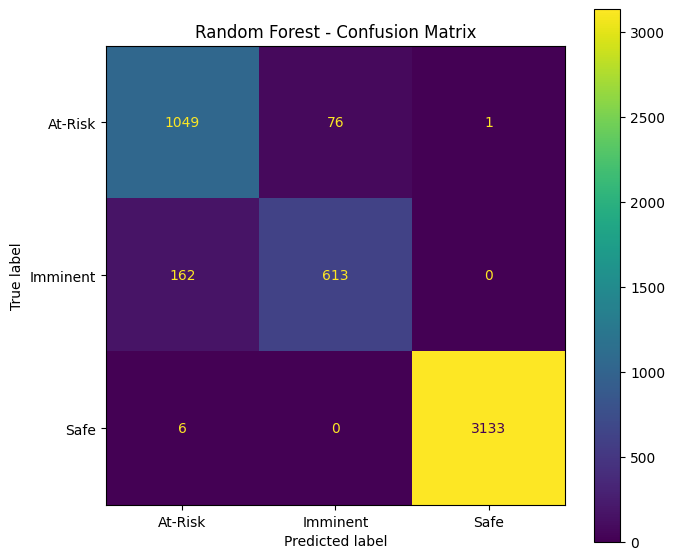

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = ["At-Risk", "Imminent", "Safe"]
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=labels
)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=labels
)
disp.plot(ax=ax)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()
cm_rf = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=labels
)
disp.plot(ax=ax)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
rf_classifier = random_forest_model.named_steps["classifier"]
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})
importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
print("Top 20 Random Forest Features:")
print(
    importance_df.head(20).to_string(index=False)
)

Top 20 Random Forest Features:
                           Feature  Importance
            numeric__days_of_cover    0.241916
      numeric__days_of_cover_ratio    0.198617
              numeric__reorder_gap    0.180796
            numeric__closing_stock    0.058184
    numeric__lead_time_days_actual    0.037804
            numeric__opening_stock    0.031104
  numeric__reliability_score_clean    0.024601
        numeric__sales_velocity_7d    0.019666
  numeric__lead_time_days_expected    0.018004
            numeric__reorder_point    0.016820
  numeric__lead_time_variance_days    0.016352
      numeric__base_lead_time_days    0.015898
     categorical__reorder_placed_N    0.012858
     categorical__reorder_placed_Y    0.012355
           numeric__units_demanded    0.012210
               numeric__units_sold    0.011313
        numeric__is_recent_reorder    0.009247
             numeric__day_of_month    0.008422
          numeric__shelf_life_days    0.008223
numeric__days_since_festival_

In [12]:
reduced_features = [
    col for col in feature_columns
    if col not in [
        "days_of_cover",
        "days_of_cover_ratio",
        "reorder_gap"
    ]
]
X_reduced = model_df[reduced_features].copy()
X_train_reduced = X_reduced.loc[train_mask].copy()
X_test_reduced = X_reduced.loc[test_mask].copy()
print("Full feature count:", len(feature_columns))
print("Reduced feature count:", len(reduced_features))
numeric_reduced = X_train_reduced.select_dtypes(
    exclude=["object"]
).columns.tolist()
categorical_reduced = X_train_reduced.select_dtypes(
    include=["object"]
).columns.tolist()
numeric_pipeline_reduced = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline_reduced = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])
preprocessor_reduced = ColumnTransformer([
    ("numeric", numeric_pipeline_reduced, numeric_reduced),
    ("categorical", categorical_pipeline_reduced, categorical_reduced)
])
rf_reduced_model = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])
rf_reduced_model.fit(
    X_train_reduced,
    y_train
)
rf_reduced_predictions = rf_reduced_model.predict(
    X_test_reduced
)
reduced_accuracy = accuracy_score(
    y_test,
    rf_reduced_predictions
)
reduced_macro_f1 = f1_score(
    y_test,
    rf_reduced_predictions,
    average="macro"
)
print("\nReduced Random Forest")
print("---------------------")
print("Accuracy :", round(reduced_accuracy, 4))
print("Macro-F1 :", round(reduced_macro_f1, 4))

Full feature count: 33
Reduced feature count: 30

Reduced Random Forest
---------------------
Accuracy : 0.8486
Macro-F1 : 0.7744


In [13]:
print("REDUCED RANDOM FOREST")
print("====================")
print(
    classification_report(
        y_test,
        rf_reduced_predictions,
        labels=["At-Risk", "Imminent", "Safe"],
        zero_division=0
    )
)

REDUCED RANDOM FOREST
              precision    recall  f1-score   support

     At-Risk       0.71      0.56      0.62      1126
    Imminent       0.87      0.68      0.77       775
        Safe       0.88      0.99      0.93      3139

    accuracy                           0.85      5040
   macro avg       0.82      0.74      0.77      5040
weighted avg       0.84      0.85      0.84      5040



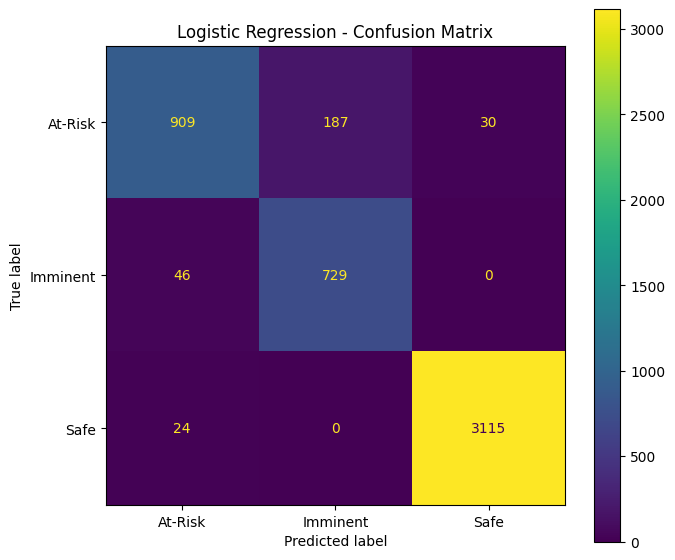

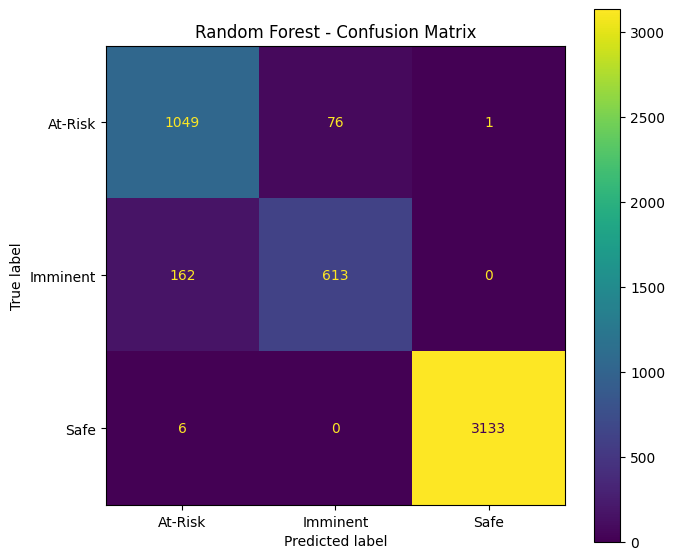

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = ["At-Risk", "Imminent", "Safe"]
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=labels
)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=labels
)
disp.plot(ax=ax)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()
cm_rf = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=labels
)
disp.plot(ax=ax)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

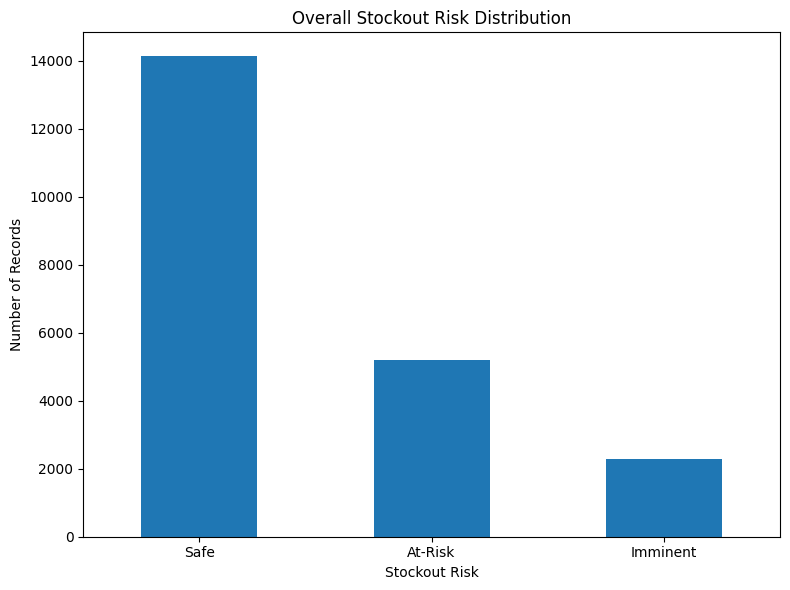

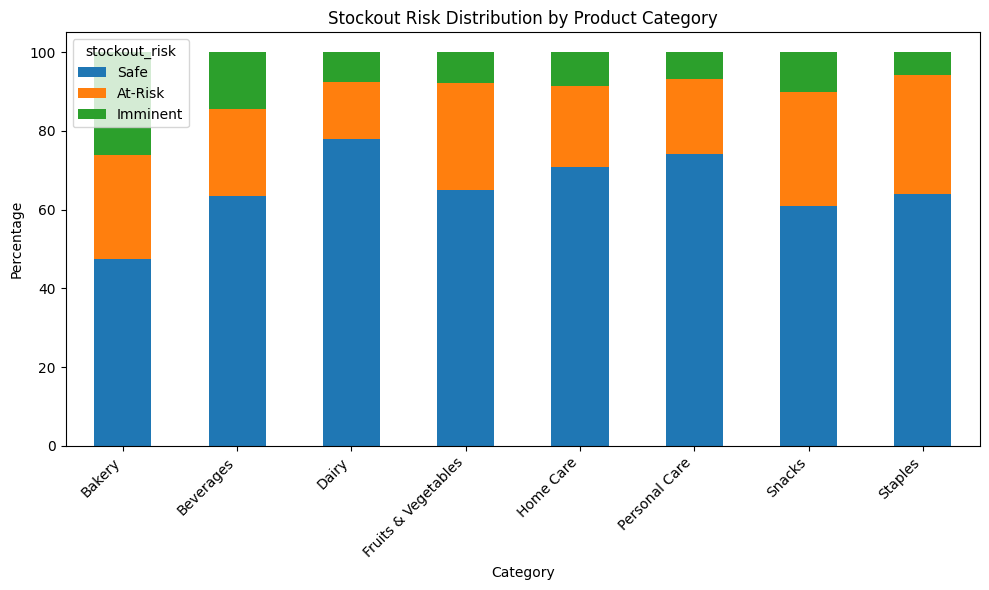

In [15]:
import matplotlib.pyplot as plt
risk_counts = model_df["stockout_risk"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
risk_counts.reindex(
    ["Safe", "At-Risk", "Imminent"]
).plot(
    kind="bar",
    ax=ax
)
ax.set_title("Overall Stockout Risk Distribution")
ax.set_xlabel("Stockout Risk")
ax.set_ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
category_risk = pd.crosstab(
    model_df["category"],
    model_df["stockout_risk"],
    normalize="index"
) * 100
category_risk = category_risk[
    ["Safe", "At-Risk", "Imminent"]
]
fig, ax = plt.subplots(figsize=(10, 6))
category_risk.plot(
    kind="bar",
    stacked=True,
    ax=ax
)
ax.set_title("Stockout Risk Distribution by Product Category")
ax.set_xlabel("Category")
ax.set_ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

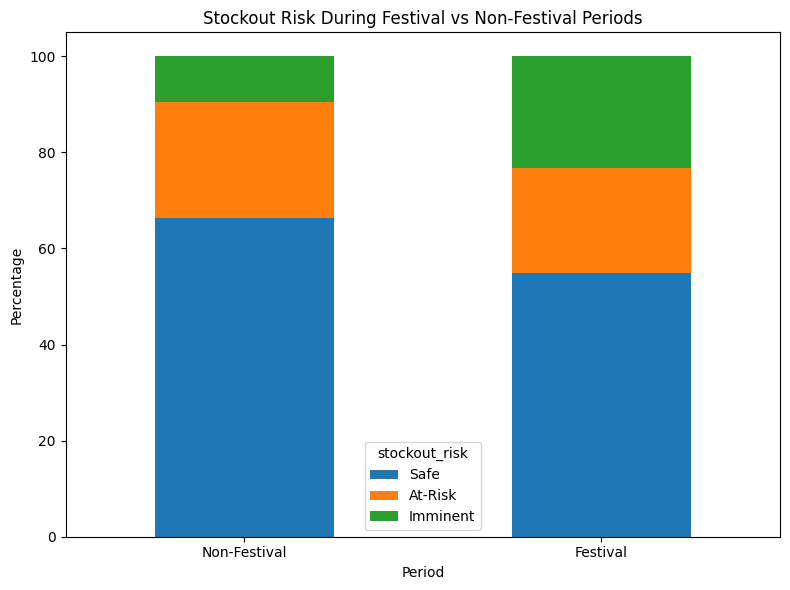

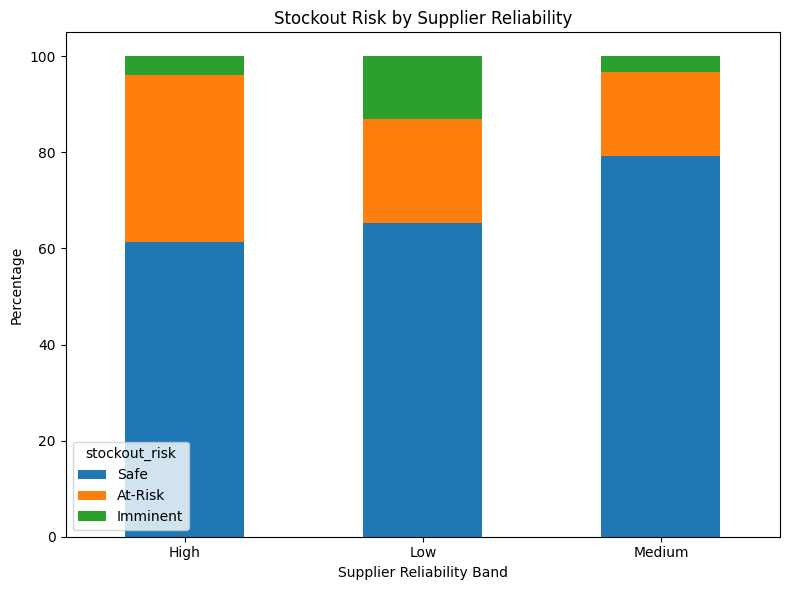

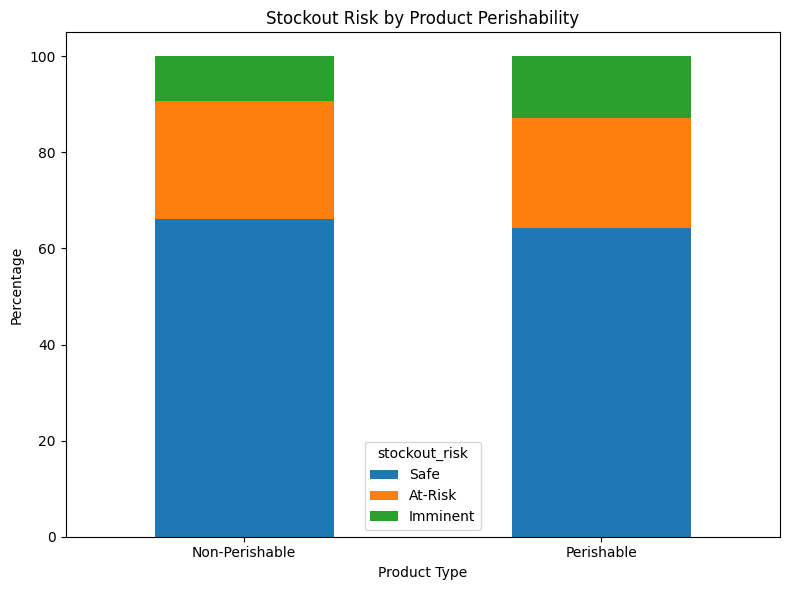

In [16]:
import matplotlib.pyplot as plt
festival_risk = pd.crosstab(
    model_df["is_festival_week"],
    model_df["stockout_risk"],
    normalize="index"
) * 100
festival_risk = festival_risk[
    ["Safe", "At-Risk", "Imminent"]
]
festival_risk.index = [
    "Non-Festival",
    "Festival"
]
fig, ax = plt.subplots(figsize=(8, 6))
festival_risk.plot(
    kind="bar",
    stacked=True,
    ax=ax
)
ax.set_title("Stockout Risk During Festival vs Non-Festival Periods")
ax.set_xlabel("Period")
ax.set_ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
supplier_risk = pd.crosstab(
    model_df["reliability_band"],
    model_df["stockout_risk"],
    normalize="index"
) * 100
supplier_risk = supplier_risk[
    ["Safe", "At-Risk", "Imminent"]
]
fig, ax = plt.subplots(figsize=(8, 6))
supplier_risk.plot(
    kind="bar",
    stacked=True,
    ax=ax
)
ax.set_title("Stockout Risk by Supplier Reliability")
ax.set_xlabel("Supplier Reliability Band")
ax.set_ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
perishable_risk = pd.crosstab(
    model_df["is_perishable"],
    model_df["stockout_risk"],
    normalize="index"
) * 100
perishable_risk = perishable_risk[
    ["Safe", "At-Risk", "Imminent"]
]
perishable_risk.index = [
    "Non-Perishable",
    "Perishable"
]
fig, ax = plt.subplots(figsize=(8, 6))
perishable_risk.plot(
    kind="bar",
    stacked=True,
    ax=ax
)
ax.set_title("Stockout Risk by Product Perishability")
ax.set_xlabel("Product Type")
ax.set_ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
print("==============================================")
print("FINAL BUSINESS INSIGHTS")
print("==============================================")
print("\n1. OVERALL STOCKOUT RISK")
overall_risk = (
    model_df["stockout_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(overall_risk)
print("\n2. IMMINENT RISK: FESTIVAL VS NON-FESTIVAL")
festival_imminent = (
    model_df.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .round(2)
)
print(festival_imminent)
print("\n3. IMMINENT RISK BY SUPPLIER RELIABILITY")
supplier_imminent = (
    model_df.groupby("reliability_band")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .round(2)
)
print(supplier_imminent)
print("\n4. IMMINENT RISK BY PERISHABILITY")
perishable_imminent = (
    model_df.groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
    .round(2)
)
print(perishable_imminent)
print("\n5. RISK BY CATEGORY")
category_summary = pd.crosstab(
    model_df["category"],
    model_df["stockout_risk"],
    normalize="index"
).mul(100).round(2)
print(category_summary)
print("\n6. HIGHEST IMMINENT-RISK CATEGORIES")
highest_categories = (
    category_summary["Imminent"]
    .sort_values(ascending=False)
)
print(highest_categories)

FINAL BUSINESS INSIGHTS

1. OVERALL STOCKOUT RISK
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64

2. IMMINENT RISK: FESTIVAL VS NON-FESTIVAL
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64

3. IMMINENT RISK BY SUPPLIER RELIABILITY
reliability_band
High       3.82
Low       13.07
Medium     3.26
Name: stockout_risk, dtype: float64

4. IMMINENT RISK BY PERISHABILITY
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64

5. RISK BY CATEGORY
stockout_risk        At-Risk  Imminent   Safe
category                                     
Bakery                 26.34     26.11  47.55
Beverages              22.08     14.55  63.37
Dairy                  14.48      7.54  77.98
Fruits & Vegetables    27.19      7.93  64.88
Home Care              20.60      8.52  70.88
Personal Care          19.17      6.79  74.05
Snacks                 28.98     10.19  60.83
Staples                30.14      5.83  64.03

In [18]:
final_results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Random Forest",
        "Random Forest (Reduced)"
    ],
    "Features": [
        33,
        33,
        33,
        30
    ],
    "Accuracy": [
        0.6228,
        0.9431,
        0.9514,
        0.8486
    ],
    "Macro-F1": [
        0.2559,
        0.9058,
        0.9106,
        0.7744
    ]
})
print("FINAL MODEL RESULTS")
print("===================")
print(final_results.to_string(index=False))

FINAL MODEL RESULTS
                  Model  Features  Accuracy  Macro-F1
         Dummy Baseline        33    0.6228    0.2559
    Logistic Regression        33    0.9431    0.9058
          Random Forest        33    0.9514    0.9106
Random Forest (Reduced)        30    0.8486    0.7744


In [19]:
final_results.to_csv(
    "final_model_results.csv",
    index=False
)
print("Saved: final_model_results.csv")

Saved: final_model_results.csv


In [20]:
top_features = importance_df.head(10).copy()
top_features["Importance_Percent"] = (
    top_features["Importance"] * 100
).round(2)
print("TOP 10 RANDOM FOREST FEATURES")
print("=============================")
print(
    top_features[
        ["Feature", "Importance_Percent"]
    ].to_string(index=False)
)

TOP 10 RANDOM FOREST FEATURES
                         Feature  Importance_Percent
          numeric__days_of_cover               24.19
    numeric__days_of_cover_ratio               19.86
            numeric__reorder_gap               18.08
          numeric__closing_stock                5.82
  numeric__lead_time_days_actual                3.78
          numeric__opening_stock                3.11
numeric__reliability_score_clean                2.46
      numeric__sales_velocity_7d                1.97
numeric__lead_time_days_expected                1.80
          numeric__reorder_point                1.68


In [21]:
import pandas as pd
model_comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.6228,
        0.9431,
        0.9514
    ],
    "Macro-F1": [
        0.2559,
        0.9058,
        0.9106
    ]
})
model_comparison["Accuracy_Percent"] = (
    model_comparison["Accuracy"] * 100
).round(2)
model_comparison

,Model,Accuracy,Macro-F1,Accuracy_Percent
0,Dummy Baseline,0.6228,0.2559,62.28
1,Logistic Regression,0.9431,0.9058,94.31
2,Random Forest,0.9514,0.9106,95.14


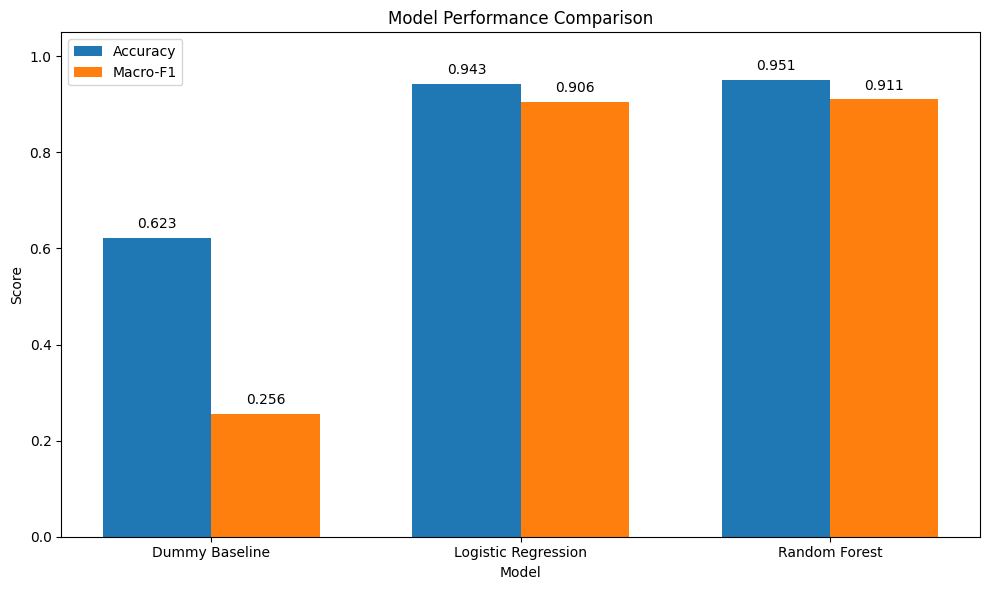

In [22]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(len(model_comparison))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(
    x - width/2,
    model_comparison["Accuracy"],
    width,
    label="Accuracy"
)
plt.bar(
    x + width/2,
    model_comparison["Macro-F1"],
    width,
    label="Macro-F1"
)
plt.xticks(x, model_comparison["Model"])
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.legend()
for i, value in enumerate(model_comparison["Accuracy"]):
    plt.text(i - width/2, value + 0.02, f"{value:.3f}",
             ha="center")
for i, value in enumerate(model_comparison["Macro-F1"]):
    plt.text(i + width/2, value + 0.02, f"{value:.3f}",
             ha="center")
plt.tight_layout()
plt.show()

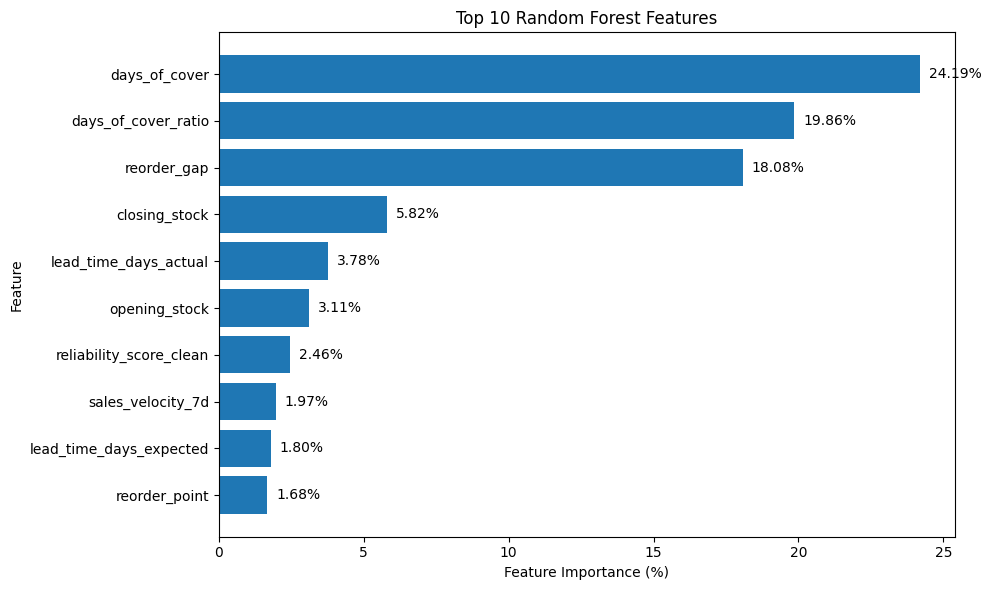

In [23]:
top_features = pd.DataFrame({
    "Feature": [
        "days_of_cover",
        "days_of_cover_ratio",
        "reorder_gap",
        "closing_stock",
        "lead_time_days_actual",
        "opening_stock",
        "reliability_score_clean",
        "sales_velocity_7d",
        "lead_time_days_expected",
        "reorder_point"
    ],
    "Importance": [
        24.19,
        19.86,
        18.08,
        5.82,
        3.78,
        3.11,
        2.46,
        1.97,
        1.80,
        1.68
    ]
})
top_features = top_features.sort_values(
    "Importance",
    ascending=True
)
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Features")
for i, value in enumerate(top_features["Importance"]):
    plt.text(
        value + 0.3,
        i,
        f"{value:.2f}%",
        va="center"
    )
plt.tight_layout()
plt.show()

In [24]:
top_3_importance = (
    top_features["Importance"]
    .nlargest(3)
    .sum()
)
print("==============================================")
print("KEY BUSINESS INSIGHTS")
print("==============================================")
print(f"\nTop 3 features contribution: {top_3_importance:.2f}%")
print("\nMost important feature:")
print("Days of Cover - 24.19%")
print("\nSecond most important feature:")
print("Days of Cover Ratio - 19.86%")
print("\nThird most important feature:")
print("Reorder Gap - 18.08%")
print("\nFestival vs Non-Festival Imminent Risk:")
print("Festival Week    : 23.31%")
print("Non-Festival     : 9.51%")
print("\nRandom Forest Performance:")
print("Accuracy         : 95.14%")
print("Macro-F1         : 0.9106")

KEY BUSINESS INSIGHTS

Top 3 features contribution: 62.13%

Most important feature:
Days of Cover - 24.19%

Second most important feature:
Days of Cover Ratio - 19.86%

Third most important feature:
Reorder Gap - 18.08%

Festival vs Non-Festival Imminent Risk:
Festival Week    : 23.31%
Non-Festival     : 9.51%

Random Forest Performance:
Accuracy         : 95.14%
Macro-F1         : 0.9106


In [25]:
best_model = model_comparison.loc[
    model_comparison["Macro-F1"].idxmax()
]
print("==============================================")
print("FINAL MODEL SELECTION")
print("==============================================")
print(f"Selected Model : {best_model['Model']}")
print(f"Accuracy       : {best_model['Accuracy']:.4f}")
print(f"Macro-F1       : {best_model['Macro-F1']:.4f}")

FINAL MODEL SELECTION
Selected Model : Random Forest
Accuracy       : 0.9514
Macro-F1       : 0.9106


In [27]:
# Check variables currently available
%whos

Variable                       Type                      Data/Info
------------------------------------------------------------------
ColumnTransformer              ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
ConfusionMatrixDisplay         type                      <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
DummyClassifier                type                      <class 'sklearn.dummy.DummyClassifier'>
LogisticRegression             type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder                  type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                       ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier         ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
SimpleImputer                  type                      <class 'sklearn.impute._base.SimpleImputer'>
StandardS

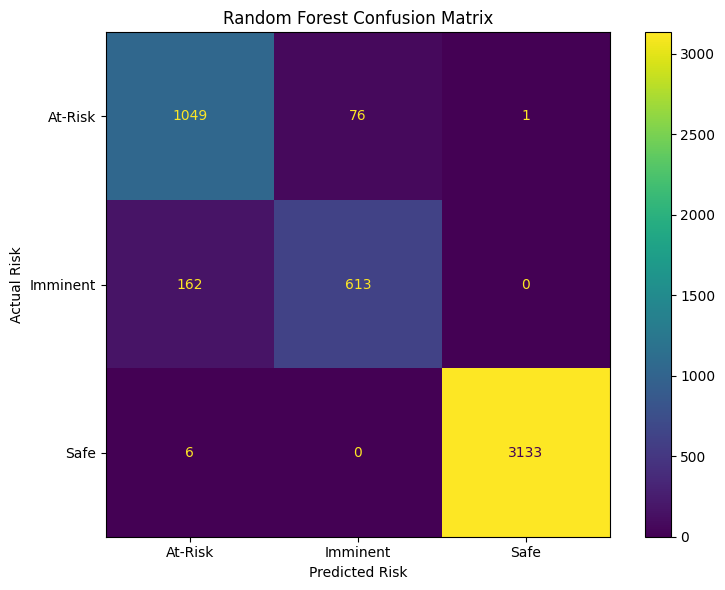

In [28]:
# ==============================================
# RANDOM FOREST CONFUSION MATRIX
# ==============================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use predictions already generated
y_pred_rf = rf_predictions

# Confusion matrix
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["At-Risk", "Imminent", "Safe"]
)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["At-Risk", "Imminent", "Safe"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, values_format="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.tight_layout()
plt.show()

In [29]:
# ==============================================
# CONFUSION MATRIX VALUES
# ==============================================

print("==============================================")
print("RANDOM FOREST CONFUSION MATRIX")
print("==============================================")

print("\n                 Predicted")
print("              At-Risk  Imminent  Safe")
print(
    f"Actual At-Risk  {cm_rf[0,0]:5d}     {cm_rf[0,1]:5d}   {cm_rf[0,2]:5d}"
)
print(
    f"Actual Imminent {cm_rf[1,0]:5d}     {cm_rf[1,1]:5d}   {cm_rf[1,2]:5d}"
)
print(
    f"Actual Safe     {cm_rf[2,0]:5d}     {cm_rf[2,1]:5d}   {cm_rf[2,2]:5d}"
)

RANDOM FOREST CONFUSION MATRIX

                 Predicted
              At-Risk  Imminent  Safe
Actual At-Risk   1049        76       1
Actual Imminent   162       613       0
Actual Safe         6         0    3133


In [30]:
# ==============================================
# FINAL RANDOM FOREST METRICS
# ==============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(
    y_test, y_pred_rf, average="macro"
)
recall_rf = recall_score(
    y_test, y_pred_rf, average="macro"
)
f1_rf = f1_score(
    y_test, y_pred_rf, average="macro"
)

print("==============================================")
print("FINAL RANDOM FOREST PERFORMANCE")
print("==============================================")

print(f"Accuracy        : {accuracy_rf:.4f}")
print(f"Macro Precision : {precision_rf:.4f}")
print(f"Macro Recall    : {recall_rf:.4f}")
print(f"Macro F1        : {f1_rf:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

FINAL RANDOM FOREST PERFORMANCE
Accuracy        : 0.9514
Macro Precision : 0.9171
Macro Recall    : 0.9069
Macro F1        : 0.9106

Classification Report:
              precision    recall  f1-score   support

     At-Risk     0.8620    0.9316    0.8954      1126
    Imminent     0.8897    0.7910    0.8374       775
        Safe     0.9997    0.9981    0.9989      3139

    accuracy                         0.9514      5040
   macro avg     0.9171    0.9069    0.9106      5040
weighted avg     0.9520    0.9514    0.9509      5040



In [32]:
# ==============================================
# FINAL BUSINESS RISK ANALYSIS - TEST SET
# ==============================================

# Use only the test-set rows
final_business_analysis = X_test.copy()

# Add actual and predicted risk
final_business_analysis["actual_risk"] = y_test.values
final_business_analysis["predicted_risk"] = rf_predictions

print("==============================================")
print("FINAL BUSINESS RISK PREDICTIONS")
print("==============================================")

print("\nTest Set Size:")
print(len(final_business_analysis))

print("\nActual Risk Distribution (%):")
print(
    final_business_analysis["actual_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPredicted Risk Distribution (%):")
print(
    final_business_analysis["predicted_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

FINAL BUSINESS RISK PREDICTIONS

Test Set Size:
5040

Actual Risk Distribution (%):
actual_risk
Safe        62.28
At-Risk     22.34
Imminent    15.38
Name: proportion, dtype: float64

Predicted Risk Distribution (%):
predicted_risk
Safe        62.18
At-Risk     24.15
Imminent    13.67
Name: proportion, dtype: float64


In [33]:
# ==============================================
# PREDICTED RISK: FESTIVAL VS NON-FESTIVAL
# ==============================================

festival_prediction = pd.crosstab(
    final_business_analysis["is_festival_week"],
    final_business_analysis["predicted_risk"],
    normalize="index"
) * 100

festival_prediction = festival_prediction.round(2)

print("==============================================")
print("PREDICTED RISK BY FESTIVAL STATUS")
print("==============================================")

print(festival_prediction)

PREDICTED RISK BY FESTIVAL STATUS
predicted_risk    At-Risk  Imminent   Safe
is_festival_week                          
N                   23.53     11.44  65.03
Y                   27.29     25.00  47.71


In [34]:
# ==============================================
# PREDICTED RISK BY CATEGORY
# ==============================================

category_prediction = pd.crosstab(
    final_business_analysis["category"],
    final_business_analysis["predicted_risk"],
    normalize="index"
) * 100

category_prediction = category_prediction.round(2)

print("==============================================")
print("PREDICTED RISK BY CATEGORY")
print("==============================================")

print(category_prediction)

PREDICTED RISK BY CATEGORY
predicted_risk       At-Risk  Imminent   Safe
category                                     
Bakery                 25.00     41.87  33.13
Beverages              27.98     21.43  50.60
Dairy                   7.48      7.48  85.03
Fruits & Vegetables    26.46      7.14  66.40
Home Care              14.48      8.33  77.18
Personal Care          13.10      7.48  79.42
Snacks                 40.08     15.34  44.58
Staples                30.65      5.06  64.29


In [35]:
# ==============================================
# HIGHEST IMMINENT-RISK CATEGORIES
# ==============================================

highest_imminent_categories = (
    category_prediction["Imminent"]
    .sort_values(ascending=False)
)

print("==============================================")
print("HIGHEST IMMINENT-RISK CATEGORIES")
print("==============================================")

print(highest_imminent_categories)

HIGHEST IMMINENT-RISK CATEGORIES
category
Bakery                 41.87
Beverages              21.43
Snacks                 15.34
Home Care               8.33
Personal Care           7.48
Dairy                   7.48
Fruits & Vegetables     7.14
Staples                 5.06
Name: Imminent, dtype: float64


In [36]:
# ==============================================
# BUSINESS PRIORITY MATRIX
# ==============================================

priority_summary = category_prediction.copy()

priority_summary["Priority_Score"] = (
    priority_summary["Imminent"] * 2
    + priority_summary["At-Risk"]
)

priority_summary = priority_summary.sort_values(
    "Priority_Score",
    ascending=False
)

print("==============================================")
print("BUSINESS PRIORITY MATRIX")
print("==============================================")

print(
    priority_summary[
        ["At-Risk", "Imminent", "Safe", "Priority_Score"]
    ].round(2)
)

BUSINESS PRIORITY MATRIX
predicted_risk       At-Risk  Imminent   Safe  Priority_Score
category                                                     
Bakery                 25.00     41.87  33.13          108.74
Beverages              27.98     21.43  50.60           70.84
Snacks                 40.08     15.34  44.58           70.76
Staples                30.65      5.06  64.29           40.77
Fruits & Vegetables    26.46      7.14  66.40           40.74
Home Care              14.48      8.33  77.18           31.14
Personal Care          13.10      7.48  79.42           28.06
Dairy                   7.48      7.48  85.03           22.44


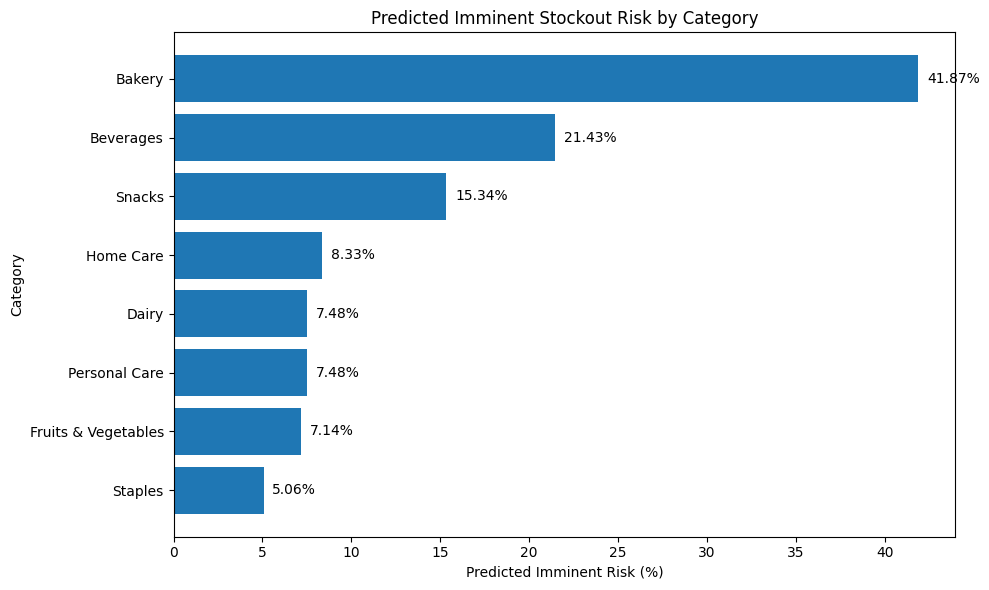

In [37]:
# ==============================================
# CATEGORY-WISE IMMINENT RISK
# ==============================================

imminent_by_category = (
    category_prediction["Imminent"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    imminent_by_category.index,
    imminent_by_category.values
)

plt.xlabel("Predicted Imminent Risk (%)")
plt.ylabel("Category")
plt.title("Predicted Imminent Stockout Risk by Category")

for i, value in enumerate(imminent_by_category.values):
    plt.text(
        value + 0.5,
        i,
        f"{value:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()